In [ ]:
from temp_camera import *

In [ ]:
from mbloodmoon.images import upscale, downscale
from mbloodmoon.mask import encode, decode


def sky_upscaling(
    sky: npt.NDArray,
    base_camera: CodedMaskCamera,
    upscaled_camera: CodedMaskCamera,
) -> npt.NDArray:
    """
    Upscales the sky by redefining the binning structure, taking into
    account that in Coded Aperture Imaging applications the sky is a
    decoded image obtained by a correlation operation.

    Args:
        sky (npt.NDArray):
            Input 2D sky.
        base_camera (CodedMaskCamera):
            CodedMaskCamera instance with info on input sky binning.
        upscaled_camera (CodedMaskCamera):
            CodedMaskCamera instance with info on upscaled binning.

    Returns:
        output (npt.NDArray): Oversampled sky.
    
    Notes:
        - The detector total sum is conserved through linear interpolation.
        - This method does not perform a "standard" oversampling due to the
          way the sky is obtained (see `astropy.nndata.block_replicate()`).
    """
    upscaling = UpscaleFactor(
        upscaled_camera.upscale_f.x - base_camera.upscale_f.x + 1,
        upscaled_camera.upscale_f.y - base_camera.upscale_f.y + 1,
    )

    # TODO:
    #   - encode on full-plate detector with 1
    #   - try encoding with full matrices and then take central
    #     part of the decoding (corresponding to the oversampled sky)
    #       -> with full correlation the decoded upscaled sky should be accurate
    #       -> a problem could be that the matrices get to be very big
    detector = upscale(
        encode(base_camera, sky),
        upscaling.y,
        upscaling.x,
    )
    return decode(upscaled_camera, detector)

def sky_downscaling(
    sky: npt.NDArray,
    base_camera: CodedMaskCamera,
    downscaled_camera: CodedMaskCamera,
) -> npt.NDArray:
    """
    Downscales the sky by redefining the binning structure, taking into
    account that in Coded Aperture Imaging applications the sky is a
    decoded image obtained by a correlation operation.

    Args:
        sky (npt.NDArray):
            Input 2D sky.
        base_camera (CodedMaskCamera):
            CodedMaskCamera instance with info on input sky binning.
        downscaled_camera (CodedMaskCamera):
            CodedMaskCamera instance with info on downscaled binning.

    Returns:
        output (npt.NDArray): Downsampled sky.
    
    Notes:
        - The detector total sum is conserved through linear interpolation.
        - This method does not perform a "standard" downsampling due to the
          way the sky is obtained (see `astropy.nndata.block_replicate()`).
    """    
    downscaling = UpscaleFactor(
        base_camera.upscale_f.x - downscaled_camera.upscale_f.x + 1,
        base_camera.upscale_f.y - downscaled_camera.upscale_f.y + 1,
    )
    detector = downscale(
        encode(base_camera, sky),
        downscaling.y,
        downscaling.x,
    )
    return decode(downscaled_camera, detector)

In [ ]:
from mbloodmoon.mask import encode, decode

def dummy_sky_up(
    sky: np.array,
    base_camera: CodedMaskCamera,
    upscaled_camera: CodedMaskCamera,
) -> np.array:
    
    upscaling = UpscaleFactor(
        upscaled_camera.upscale_f.x - base_camera.upscale_f.x + 1,
        upscaled_camera.upscale_f.y - base_camera.upscale_f.y + 1,
    )
    
    # aperture = base_camera.mask.sum() / base_camera.mask.size
    # det_eff_response = base_camera.bulk.sum() / base_camera.bulk.size
    # counts_norm = 1 / (aperture * det_eff_response)
    counts_norm = 1

    encoded_det = counts_norm * encode(base_camera, sky)
    detector = upscale(encoded_det, upscaling)
    norm = 1  # / adim effective area   # correction matrix due to source pos
    up_sky = norm * decode(upscaled_camera, detector)

    print(
        f"Base WFM detector shape: {base_camera.detector_shape}\n"
        f"Encoded detector shape: {encoded_det.shape}\n"
        f"Upscaled WFM detector shape: {upscaled_camera.detector_shape}\n"
        f"Upscaled encoded detector shape: {detector.shape}\n"
        f"Upscaled/Base WFM detector shape: {np.array(upscaled_camera.detector_shape) / np.array(base_camera.detector_shape)}\n\n"

        f"Base WFM sky shape: {base_camera.sky_shape}\n"
        f"Decoded sky shape: {sky.shape}\n"
        f"Upscaled WFM sky shape: {upscaled_camera.sky_shape}\n"
        f"Upscaled decoded sky shape: {up_sky.shape}\n\n"

        f"Sum encoded detector: {encoded_det.sum()}\n"
        f"Sum upscaled detector: {detector.sum()}\n"
        f"Min/Max sky: {sky.min(), sky.max()}\n"
        f"Sum sky: {sky.sum()}\n"
        f"Min/Max upscaled sky: {up_sky.min(), up_sky.max()}\n"
        f"Sum upscaled sky: {up_sky.sum()}\n"
    )
    return up_sky



mask_path = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits"
# mask_path = "/mnt/d/PhD_AASS/Coding/Images_fits/wfm_mask.fits"
wfm_base = codedmask(
    mask_filepath=mask_path,
    upscale_x=3,
    upscale_y=1,
)

n, m = wfm_base.sky_shape
y = n // 2 + n // 8
x = m // 2 - m // 8

sky = np.zeros((n, m)); sky[y, x] = 1e5

wfm_up = codedmask(
    mask_filepath=mask_path,
    upscale_x=3,
    upscale_y=7,
)


up_sky = dummy_sky_up(
    sky=sky,
    base_camera=wfm_base,
    upscaled_camera=wfm_up,
)

(650, 1040) (650, 3120) [0. 1.] 552240.0
(384, 1896) (384, 1896) [0. 1.] 552240.0
[0. 1.] 552240.0
n_zero_resp_pxs_y: 0
delta len det bins y: 0
n_zero_resp_pxs_x: 0
delta len det bins x: 0

(650, 1040) (4550, 3120) [0. 1.] 3865680.0
(2688, 1896) (2688, 1896) [0. 1.] 3865680.0
[0. 1.] 3853200.0
n_zero_resp_pxs_y: 8
delta len det bins y: -8
n_zero_resp_pxs_x: 0
delta len det bins x: 0

Base WFM detector shape: (384, 1896)
Encoded detector shape: (384, 1896)
Upscaled WFM detector shape: (2688, 1896)
Upscaled encoded detector shape: (2688, 1896)
Upscaled/Base WFM detector shape: [7. 1.]

Base WFM sky shape: (1033, 5015)
Decoded sky shape: (1033, 5015)
Upscaled WFM sky shape: (7237, 5015)
Upscaled decoded sky shape: (7237, 5015)

Sum encoded detector: 95913217364.63216
Sum upscaled detector: 95913217364.63213
Min/Max sky: (np.float64(0.0), np.float64(100000.0))
Sum sky: 100000.0
Min/Max upscaled sky: (np.float64(-3645240582.491308), np.float64(95888978188.31837))
Sum upscaled sky: -0.141500

In [20]:
up_sky[
    (wfm_up.upscale_f.y - wfm_base.upscale_f.y + 1) * y,
    (wfm_up.upscale_f.x - wfm_base.upscale_f.x + 1) * x,
]

np.float64(93655817879.85966)

In [ ]:
import numpy as np
from skimage.transform import resize
from scipy.ndimage import zoom

s = 10
a = np.arange(s * s).reshape(s, s)

upy, upx = 5, 5
a, resize(a, (upy, upx), order=2, mode="constant", preserve_range=True), resize(a, (upy, upx)).shape

(array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
        [60, 61, 62, 63, 64, 65, 66, 67, 68, 69],
        [70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
        [80, 81, 82, 83, 84, 85, 86, 87, 88, 89],
        [90, 91, 92, 93, 94, 95, 96, 97, 98, 99]]),
 array([[ 5.51009193,  7.45692783,  9.5004175 , 11.5566443 , 13.929226  ],
        [26.0645532 , 27.51593906, 29.50112683, 31.52586652, 34.29929753],
        [46.53194303, 47.53371232, 49.50414803, 51.54095354, 54.76117092],
        [67.06171784, 67.61521363, 69.57353902, 71.62514108, 75.29646217],
        [89.70143267, 89.80437107, 91.79269645, 93.90408753, 98.12056674]]),
 (5, 5))

In [ ]:
import sys
import tempfile

import numpy as np
import numpy.typing as npt
from astropy.wcs import WCS
from astropy.wcs.utils import pixel_to_pixel
from astropy.wcs.wcsapi import SlicedLowLevelWCS

from reproject.array_utils import iterate_chunks, sample_array_edges
from reproject.utils import parse_input_data, parse_output_projection
from reproject.mosaicking.subset_array import ReprojectedArraySubset

IS_WIN = sys.platform == "win32"


def sky_composition(
    input_data,
    output_projection,
    shape_out,
    reproject_function,
    combine_function,
) -> tuple[npt.NDArray, npt.NDArray]:
    
    # Parse the output projection to avoid having to do it for each
    wcs_out, shape_out = parse_output_projection(output_projection, shape_out=shape_out)
    output_array = np.zeros(shape_out)
    output_footprint = np.zeros(shape_out)

    on_the_fly = combine_function in ("mean", "sum")


    # Start off by reprojecting individual images to the final projection
    if not on_the_fly:
        arrays = []

    with tempfile.TemporaryDirectory(ignore_cleanup_errors=IS_WIN) as local_tmp_dir:
        for idata in range(len(input_data)):
            # We need to pre-parse the data here since we need to figure out how to
            # optimize/minimize the size of each output tile (see below).
            array_in, wcs_in = parse_input_data(input_data[idata], hdu_in=None)

            # Since we might be reprojecting small images into a large mosaic we
            # want to make sure that for each image we reproject to an array with
            # minimal footprint. We therefore find the pixel coordinates of the
            # edges of the initial image and transform this to pixel coordinates in
            # the final image to figure out the final WCS and shape to reproject to
            # for each tile. We strike a balance between transforming only the
            # input-image corners, which is fast but can cause clipping in cases of
            # significant distortion (when the edges of the input image become
            # convex in the output projection), and transforming every edge pixel,
            # which provides a lot of redundant information.
            edges = sample_array_edges(array_in.shape, n_samples=11)[::-1]
            edges_out = pixel_to_pixel(wcs_in, wcs_out, *edges)[::-1]

            # Determine the cutout parameters

            # In some cases, images might not have valid coordinates in the corners,
            # such as all-sky images or full solar disk views. In this case we skip
            # this step and just use the full output WCS for reprojection.
            ndim_out = len(shape_out)
            if np.any(np.isnan(edges_out)):
                bounds = list(zip([0] * ndim_out, shape_out, strict=False))
            else:
                bounds = []
                for idim in range(ndim_out):
                    imin = max(0, int(np.floor(edges_out[idim].min() + 0.5)))
                    imax = min(shape_out[idim], int(np.ceil(edges_out[idim].max() + 0.5)))
                    bounds.append((imin, imax))
                    if imax < imin: break

            slice_out = tuple([slice(imin, imax) for (imin, imax) in bounds])

            if isinstance(wcs_out, WCS):
                wcs_out_indiv = wcs_out[slice_out]
            else:
                wcs_out_indiv = SlicedLowLevelWCS(wcs_out.low_level_wcs, slice_out)

            shape_out_indiv = tuple([imax - imin for (imin, imax) in bounds])

            array = footprint = None

            array, footprint = reproject_function(
                (array_in, wcs_in),
                output_projection=wcs_out_indiv,
                shape_out=shape_out_indiv,
                hdu_in=None,
                output_array=array,
                output_footprint=footprint,
            )

            # For the purposes of mosaicking, we mask out NaN values from the array
            # and set the footprint to 0 at these locations.
            reset = np.isnan(array)
            array[reset] = 0.0
            footprint[reset] = 0.0

            array = ReprojectedArraySubset(array, footprint, bounds)

            if on_the_fly:
                # By default, values outside of the footprint are set to NaN
                # but we set these to 0 here to avoid getting NaNs in the
                # means/sums.
                array.array[array.footprint == 0] = 0
                output_footprint[array.view_in_original_array] += array.footprint
                # We now need to do output[view] += array * footprint but to avoid
                # the temporary array allocation from array * footprint we modify
                # array inplace, which we can do as the array will be discarded at
                # the end of the loop.
                array.array *= array.footprint
                output_array[array.view_in_original_array] += array.array

            else:
                arrays.append(array)


        if combine_function == "mean":
            with np.errstate(invalid="ignore"):
                output_array /= output_footprint

        if combine_function in ("first", "last", "min", "max"):
            if combine_function == "min":
                output_array[...] = np.inf
            elif combine_function == "max":
                output_array[...] = -np.inf

            for array in arrays:
                if combine_function == "first":
                    mask = output_footprint[array.view_in_original_array] == 0
                elif combine_function == "last":
                    mask = array.footprint > 0
                elif combine_function == "min":
                    mask = (array.footprint > 0) & (
                        array.array < output_array[array.view_in_original_array]
                    )
                elif combine_function == "max":
                    mask = (array.footprint > 0) & (
                        array.array > output_array[array.view_in_original_array]
                    )

                output_footprint[array.view_in_original_array] = np.where(
                    mask, array.footprint, output_footprint[array.view_in_original_array]
                )
                output_array[array.view_in_original_array] = np.where(
                    mask, array.array, output_array[array.view_in_original_array]
                )

    # We need to avoid potentially large memory allocation from output == 0 so
    # we operate in chunks.
    for chunk in iterate_chunks(output_array.shape, max_chunk_size=256 * 1024**2):
        output_array[chunk][output_footprint[chunk] == 0] = 0

    return output_array, output_footprint

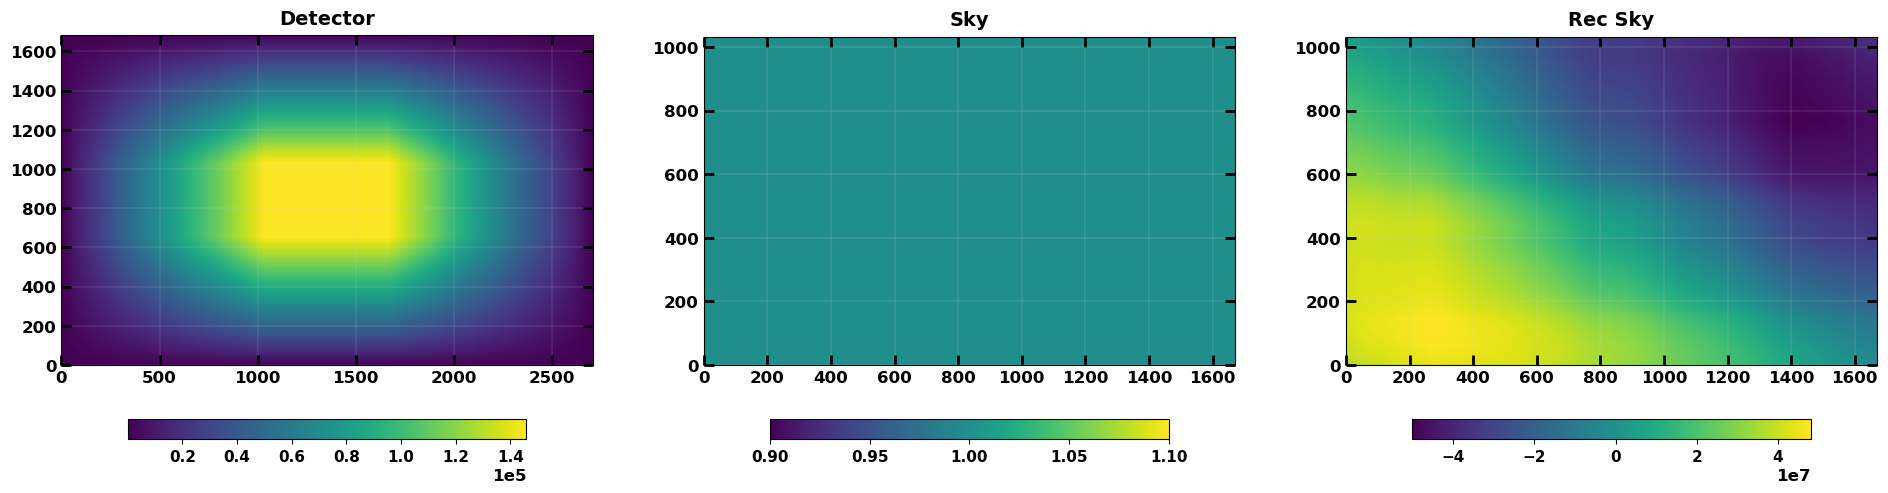

In [3]:
import numpy as np
from scipy.signal import correlate

from temp_test_sampling import *
from dummymoon.display import image_plot

def decode(
    camera: CodedMaskCamera,
    detector: npt.NDArray,
) -> npt.NDArray:
    """Reconstruct balanced sky image from detector counts using cross-correlation.

    Args:
        camera: CodedMaskCamera object containing mask and decoder patterns
        detector: 2D array of detector counts

    Returns:
        Balanced cross-correlation sky image
            - Variance map of the reconstructed sky image
    """
    cc = correlate(camera.decoder, detector, mode="full")
    sum_det, sum_bulk = map(np.sum, (detector, np.ones(detector.shape)))
    cc_bal = cc - correlate(camera.decoder, np.ones(detector.shape), mode="full") * sum_det / sum_bulk
    return cc_bal


mask_path = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits"
# mask_path = "/mnt/d/PhD_AASS/Coding/Images_fits/wfm_mask.fits"
wfm_base = codedmask(
    mask_filepath=mask_path,
    upscale_x=1,
    upscale_y=1,
)

sy, sx = wfm_base.sky_shape
sky = np.ones((sy, sx))
detector = correlate(wfm_base.mask, sky, mode="full")

my, mx = wfm_base.mask_shape
rec_sky = wfm_base.mask.sum() / wfm_base.mask.size * decode(wfm_base, detector)[
    my - 1 : sy + my - 1,
    mx - 1 : sx + mx - 1,
]

image_plot(
    input_image=[detector, sky, rec_sky],
    title=["Detector", "Sky", "Rec Sky"],
)


In [4]:
sky.shape, rec_sky.shape

((1033, 1671), (1033, 1671))

In [2]:
from IROS_pipeline import _handle_dirpaths
import mbloodmoon as bm

mask_FITS = "wfm_mask.fits"

skyfield = "GalacticCenter"
data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"

_, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
)

cam_a = "cam1a"
cam_b = "cam1b"

filepaths = bm.simulation_files(simul_data)
sdlA = bm.simulation(filepaths[cam_a]["reconstructed"])

sdlA.pointings["z"], sdlA.pointings["x"]

(CoordEquatorial(ra=266.4, dec=-28.94), CoordEquatorial(ra=266.4, dec=61.06))